**3. a) Pretrained CNN (VGG16)**
   
**b)Use VGG16 pretrained on ImageNet**

conv_base = VGG16(

    weights='imagenet',

    include_top=False,
    
    input_shape=(128,128,3)   # reduced size (faster) from 150
)

**c)Freeze the convolutional base and train only the classifier**

**conv_base.trainable = False**

**epochs=15**       
   
**batch_size=64**




Found 11229 images belonging to 6 classes.
176/176 ━━━━━━━━━━━━━━━━━━━━ 25s 138ms/step
Found 2805 images belonging to 6 classes.
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 144ms/step
Epoch 1/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5944 - loss: 1.0509 - val_accuracy: 0.8242 - val_loss: 0.4940
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8148 - loss: 0.5066 - val_accuracy: 0.8406 - val_loss: 0.4410
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8356 - loss: 0.4575 - val_accuracy: 0.8528 - val_loss: 0.4023
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8411 - loss: 0.4205 - val_accuracy: 0.8570 - val_loss: 0.3864
Epoch 5/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8573 - loss: 0.3873 - val_accuracy: 0.8617 - val_loss: 0.3804
Epoch 6/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8631 - loss: 0.3807 - val_accuracy: 0.8709 - val_loss: 0.3708
Epoch 7/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accurac

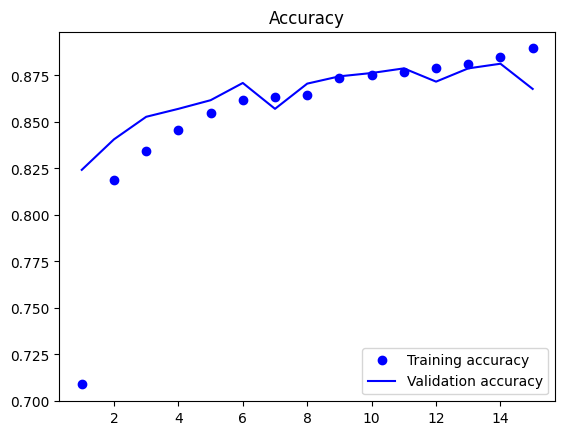

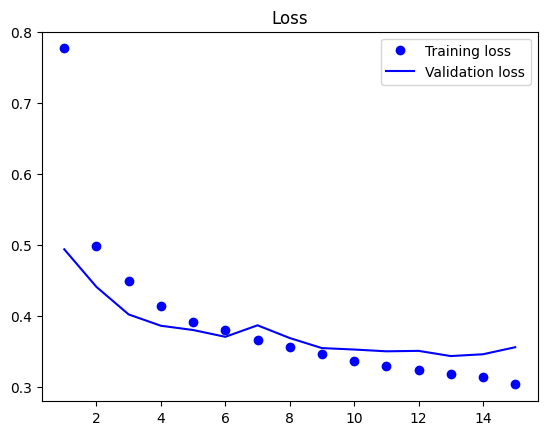

In [3]:
# Load VGG16
from tensorflow.keras.applications import VGG16

conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)   # reduced size (faster)
)

conv_base.trainable = False   # freeze for speed

# 2. Set Dataset Path
train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"


# Data Generator
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 64   # faster


def extract_features(directory):

    generator = datagen.flow_from_directory(
        directory,
        target_size=(128,128),
        batch_size=BATCH_SIZE,
        class_mode='categorical',   # multi-class
        shuffle=False
    )

    features = conv_base.predict(generator, verbose=1)
    labels = generator.classes

    return features, labels, generator.num_classes


# Extract features
train_features, train_labels, num_classes = extract_features(train_dir)
val_features, val_labels, _ = extract_features(validation_dir)


# Better than flatten (reduces size)
from tensorflow.keras.layers import GlobalAveragePooling2D

train_features = train_features.mean(axis=(1,2))
val_features = val_features.mean(axis=(1,2))


# Convert labels to categorical
from tensorflow.keras.utils import to_categorical

train_labels = to_categorical(train_labels, num_classes)
val_labels = to_categorical(val_labels, num_classes)


# Dense classifier
from tensorflow.keras import models, layers, optimizers

model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(512,)),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')   # auto classes
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),  # faster
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Train
history = model.fit(
    train_features,
    train_labels,
    epochs=15,           # reduced
    batch_size=64,
    validation_data=(val_features, val_labels)
)

# model.save("/content/drive/MyDrive/Colab Notebooks/DL/assignment/vgg16_feature_model.h5")

# Plot
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(acc)+1)

plt.plot(epochs,acc,'bo',label='Training accuracy')
plt.plot(epochs,val_acc,'b',label='Validation accuracy')
plt.legend()
plt.title('Accuracy')

plt.figure()

plt.plot(epochs,loss,'bo',label='Training loss')
plt.plot(epochs,val_loss,'b',label='Validation loss')
plt.legend()
plt.title('Loss')

plt.show()

**epochs=15**       
   
**batch_size=64**

Found 11229 images belonging to 6 classes.
176/176 ━━━━━━━━━━━━━━━━━━━━ 25s 137ms/step
Found 2805 images belonging to 6 classes.
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step
Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5593 - loss: 1.1189 - val_accuracy: 0.8278 - val_loss: 0.4965
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8068 - loss: 0.5199 - val_accuracy: 0.8367 - val_loss: 0.4414
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8325 - loss: 0.4578 - val_accuracy: 0.8499 - val_loss: 0.4117
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8500 - loss: 0.4166 - val_accuracy: 0.8513 - val_loss: 0.3934
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8525 - loss: 0.4062 - val_accuracy: 0.8602 - val_loss: 0.3929
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8589 - loss: 0.3877 - val_accuracy: 0.8581 - val_loss: 0.3859
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accurac

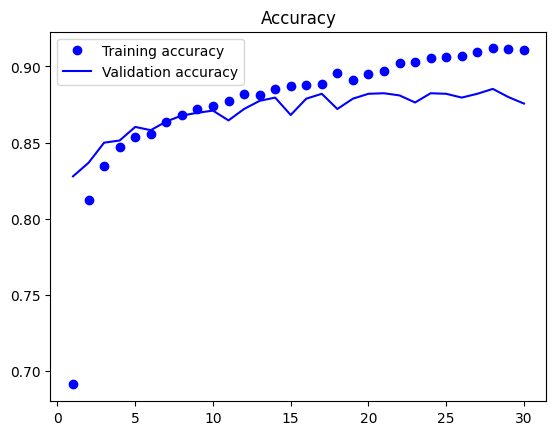

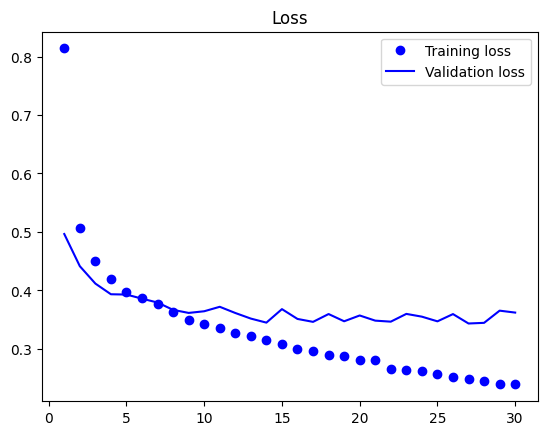

In [2]:
# Load VGG16
from tensorflow.keras.applications import VGG16

conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)   # 🔥 reduced size (faster)
)

conv_base.trainable = False   # 🔥 freeze for speed

# 2. Set Dataset Path
train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"


# Data Generator
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 64   # faster


def extract_features(directory):

    generator = datagen.flow_from_directory(
        directory,
        target_size=(128,128),
        batch_size=BATCH_SIZE,
        class_mode='categorical',   # multi-class
        shuffle=False
    )

    features = conv_base.predict(generator, verbose=1)
    labels = generator.classes

    return features, labels, generator.num_classes


# Extract features
train_features, train_labels, num_classes = extract_features(train_dir)
val_features, val_labels, _ = extract_features(validation_dir)


# Better than flatten (reduces size)
from tensorflow.keras.layers import GlobalAveragePooling2D

train_features = train_features.mean(axis=(1,2))
val_features = val_features.mean(axis=(1,2))


# Convert labels to categorical
from tensorflow.keras.utils import to_categorical

train_labels = to_categorical(train_labels, num_classes)
val_labels = to_categorical(val_labels, num_classes)


# Dense classifier
from tensorflow.keras import models, layers, optimizers

model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(512,)),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')   # auto classes
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),  # faster
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Train
history = model.fit(
    train_features,
    train_labels,
    epochs=30,           # reduced
    batch_size=64,
    validation_data=(val_features, val_labels)
)

# model.save("/content/drive/MyDrive/Colab Notebooks/DL/assignment/vgg16_feature_model.h5")

# Plot
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(acc)+1)

plt.plot(epochs,acc,'bo',label='Training accuracy')
plt.plot(epochs,val_acc,'b',label='Validation accuracy')
plt.legend()
plt.title('Accuracy')

plt.figure()

plt.plot(epochs,loss,'bo',label='Training loss')
plt.plot(epochs,val_loss,'b',label='Validation loss')
plt.legend()
plt.title('Loss')

plt.show()